# Point & Figure prototype

Companion to [renko-proto.ipynb](renko-proto.ipynb) — the same transform-then-render mapping from [notes/view-transforms.md](../notes/view-transforms.md), one step further: `calc_pnf` emits one row per *column* (X or O), and the `PointFigure` primitive binds that transform to the chart view via `Chart.get_view(transform=...)` before drawing X/O glyphs on the box grid — a genuinely new renderer, no Candlesticks reuse. Target API end to end:

```python
Chart(prices).plot(PointFigure(box_size=5.0))
```

The column frame is still ordinary prices: an X column is an up row (`open=bottom, close=top`), an O column a down row, `high`/`low` the column extremes, volume per bar (mean daily volume over the column lifetime), dated by the column start. So windowing, indicators, and panes compose exactly as with renko.


In [1]:
import sys
import numpy as np

from matplotlib.collections import LineCollection, EllipseCollection

from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.utils import col_to_numpy, detect_backend
from mplchart.model.primitive import Primitive
from mplchart.primitives import Volume

prices = sample_prices(freq="daily")

# recent window: a fixed 5pt box only suits the recent price regime — over
# the full 18y history the low-priced early years inflate the first columns
# (percentage boxes are the real fix, see Findings)
recent = prices.tail(2500)
recent.tail()


,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


## Helpers

Same date-carrying wrap as the renko prototype (`wrap_result` assumes row alignment — extension candidate).


In [2]:
def get_dates(prices):
    """datetime64 array of the prices dates — index (pandas) or first date column (polars)"""
    if detect_backend(prices) == "pandas":
        return prices.index.to_numpy()
    pl = sys.modules["polars"]
    for name, dtype in prices.schema.items():
        if dtype == pl.Date or dtype == pl.Datetime:
            return prices[name].to_numpy()
    raise ValueError("No Date or Datetime column found")


def wrap_frame(data, dates, source):
    """wrap column arrays into the source backend with their own dates"""
    if detect_backend(source) == "polars":
        pl = sys.modules["polars"]
        return pl.DataFrame({"date": dates.astype("datetime64[ns]"), **data})
    pd = sys.modules["pandas"]
    return pd.DataFrame(data, index=pd.DatetimeIndex(dates, name="date"))


## calc_pnf

Close-based with the classic 3-box reversal. An X column extends up one box at a time while close reaches `top + box`; it reverses when close falls `reversal * box` below the top, closing the column and opening an O column one box below (and symmetrically for O→X). The seed waits for the first one-box move to pick a direction.

Default box size is the mean true range, as in the renko prototype. Column start dates are strictly increasing (one close can't reverse twice), so no timestamp nudge is needed here. Volume is a per-bar rate: mean daily volume over the column lifetime.


In [3]:
def calc_pnf(prices, box_size=None, reversal=3):
    """Point & Figure columns from a prices frame — one row per column.

    Returns an OHLCV frame in the source backend: X columns are up rows
    (open=bottom, close=top), O columns down rows; high/low the column
    extremes on the box grid; volume per bar (mean daily volume over the column lifetime);
    dated by the column start.
    """
    dates = get_dates(prices)
    high = col_to_numpy(prices, "high")
    low = col_to_numpy(prices, "low")
    close = col_to_numpy(prices, "close")
    volume = col_to_numpy(prices, "volume")

    if box_size is None:
        prev = np.concatenate((close[:1], close[:-1]))
        tr = np.maximum(high - low, np.maximum(np.abs(high - prev), np.abs(low - prev)))
        box_size = float(np.nanmean(tr))

    size = float(box_size)

    tops, bottoms, dirs, idx, vols = [], [], [], [], []

    def emit(top, bottom, trend, start, vol, nbars):
        tops.append(top)
        bottoms.append(bottom)
        dirs.append(trend)
        idx.append(start)
        # volume per bar: mean daily volume over the column lifetime — a
        # participation rate, independent of box size and column height
        vols.append(vol / max(1, nbars))

    top = bottom = round(close[0] / size) * size
    trend, start = 0, 0
    accum, nbars = float(volume[0]), 1

    for i in range(1, len(close)):
        accum += float(volume[i])
        nbars += 1
        c = close[i]

        if trend == 0:
            # seed: the first one-box move sets the direction
            if c >= top + size:
                top += size * int((c - top) // size)
                trend, start = 1, i
            elif c <= bottom - size:
                bottom -= size * int((bottom - c) // size)
                trend, start = -1, i
        elif trend > 0:
            if c >= top + size:  # extend X column
                top += size * int((c - top) // size)
            elif c <= top - reversal * size:  # reverse to O
                emit(top, bottom, 1, start, accum, nbars)
                accum, nbars = 0.0, 0
                bottom = top - size * int((top - c) // size)
                top, trend, start = top - size, -1, i
        else:
            if c <= bottom - size:  # extend O column
                bottom -= size * int((bottom - c) // size)
            elif c >= bottom + reversal * size:  # reverse to X
                emit(top, bottom, -1, start, accum, nbars)
                accum, nbars = 0.0, 0
                top = bottom + size * int((c - bottom) // size)
                bottom, trend, start = bottom + size, 1, i

    if trend != 0:  # final open column
        emit(top, bottom, trend, start, accum, nbars)

    tops = np.array(tops, dtype=float)
    bottoms = np.array(bottoms, dtype=float)
    up = np.array(dirs) > 0

    data = dict(
        open=np.where(up, bottoms, tops),
        high=tops,
        low=bottoms,
        close=np.where(up, tops, bottoms),
        volume=np.array(vols, dtype=float),
    )
    return wrap_frame(data, dates[np.array(idx, dtype=int)], prices)


In [4]:
columns = calc_pnf(recent, box_size=5.0)
print(f"{len(recent)} bars -> {len(columns)} columns")
print(f"column start dates unique: {not columns.index.duplicated().any()}")
columns.tail()


2500 bars -> 27 columns
column start dates unique: True


,open,high,low,close,volume
date,,,,,
2025-02-13,230.0,245.0,230.0,245.0,4.755765e+07
2025-03-10,240.0,240.0,175.0,175.0,7.140385e+07
2025-04-09,180.0,210.0,180.0,210.0,5.844618e+07
2025-05-23,205.0,205.0,195.0,195.0,5.657634e+07
2025-07-02,200.0,275.0,200.0,275.0,5.242010e+07


## PointFigure primitive

Draws X's (two diagonal segments per box cell, `LineCollection`) and O's (`EllipseCollection` with `units="xy"` for data-coordinate sizing) on the box grid. The primitive carries the transform params (`box_size`, `reversal`) and binds the transform as its first act — `chart.get_view(transform=self.transform)`, a bound method equivalent to `functools.partial(calc_pnf, ...)` — then renders from the view. It must be the first view-toucher on the chart. The render-side box size is inferred from the grid (smallest positive gap between distinct levels) when `box_size=None` resolved to an auto value inside the calc.


In [5]:
class PointFigure(Primitive):
    """Point & Figure primitive — X/O glyphs on the box grid.

    Binds the pnf transform to the chart view (must be the first
    view-toucher), then renders the columns: up rows are X columns,
    down rows O columns, high/low the column extremes.
    """

    def __init__(self, box_size=None, reversal=3, *, width=0.8, alpha=None,
                 colorup="green", colordn="red", label="PnF"):
        self.box_size = box_size
        self.reversal = reversal
        self.width = width
        self.alpha = alpha
        self.colorup = colorup
        self.colordn = colordn
        self.label = label

    def __str__(self):
        return self.__class__.__name__

    def transform(self, prices):
        return calc_pnf(prices, box_size=self.box_size, reversal=self.reversal)

    def apply_to_chart(self, chart):
        chart.get_view(transform=self.transform)

        ax = chart.canvas.get_axes()

        prices = chart.view.slice(chart.view.prices, xcol="xloc")
        xv = col_to_numpy(prices, "xloc").astype(float)
        open_ = col_to_numpy(prices, "open")
        high = col_to_numpy(prices, "high")
        low = col_to_numpy(prices, "low")
        close = col_to_numpy(prices, "close")

        box = self.box_size
        if box is None:  # infer from the grid: smallest gap between levels
            levels = np.unique(np.round(np.concatenate([high, low]), 9))
            gaps = np.diff(levels)
            box = float(gaps[gaps > 1e-9].min())

        spacing = float(np.nanmin(np.diff(xv))) if len(xv) > 1 else 1.0
        w = spacing * self.width

        up = close >= open_
        xsegs, centers = [], []
        for x, hi, lo, u in zip(xv, high, low, up):
            for k in range(max(1, int(round((hi - lo) / box)))):
                y = lo + k * box
                if u:
                    x0, x1 = x - w * 0.4, x + w * 0.4
                    y0, y1 = y + box * 0.1, y + box * 0.9
                    xsegs.append([(x0, y0), (x1, y1)])
                    xsegs.append([(x0, y1), (x1, y0)])
                else:
                    centers.append((x, y + box / 2))

        if xsegs:
            xs = LineCollection(np.array(xsegs), colors=self.colorup,
                                linewidths=1.2, alpha=self.alpha, label=self.label)
            ax.add_collection(xs)
        if centers:
            os_ = EllipseCollection(
                widths=w * 0.8, heights=box * 0.8, angles=0, units="xy",
                offsets=np.array(centers), offset_transform=ax.transData,
                facecolors="none", edgecolors=self.colordn,
                linewidths=1.2, alpha=self.alpha,
            )
            ax.add_collection(os_)

        pts = np.column_stack([np.concatenate([xv, xv]), np.concatenate([low, high])])
        ax.update_datalim(pts)
        ax.autoscale_view()


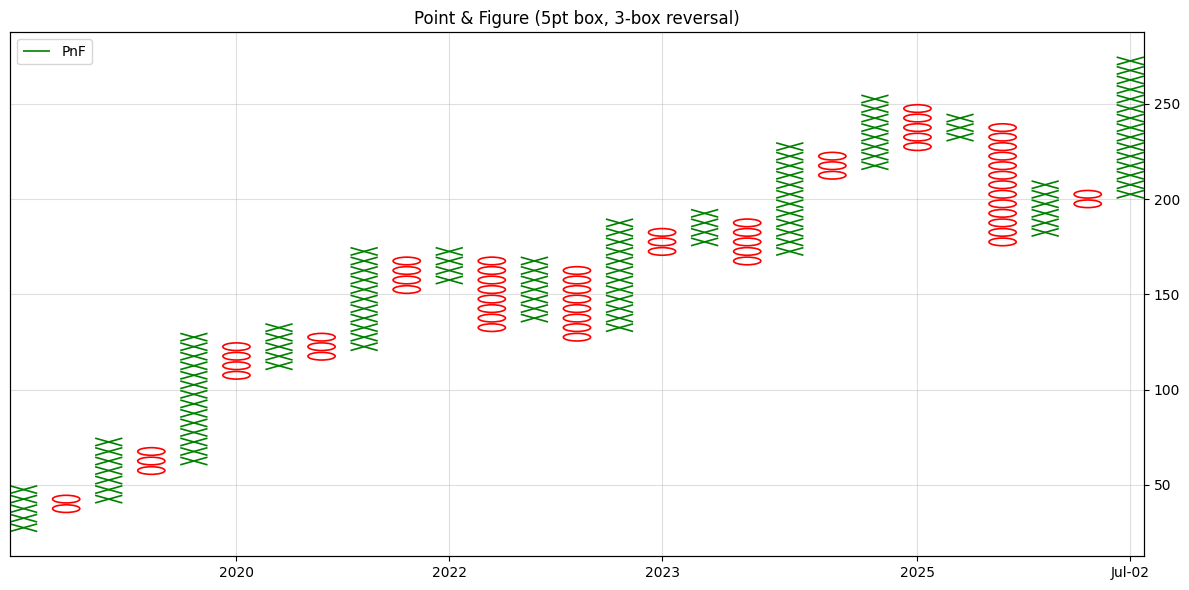

In [6]:
Chart(recent, title="Point & Figure (5pt box, 3-box reversal)", max_bars=60, figsize=(12, 6)).plot(
    PointFigure(box_size=5.0)
).show()


No transform by hand — the primitive bound it. `max_bars=60` counts *columns*; the dateaxis labels columns with their start dates.

## Composability

PointFigure binds the view first, so the rest of the plot list computes in column space.


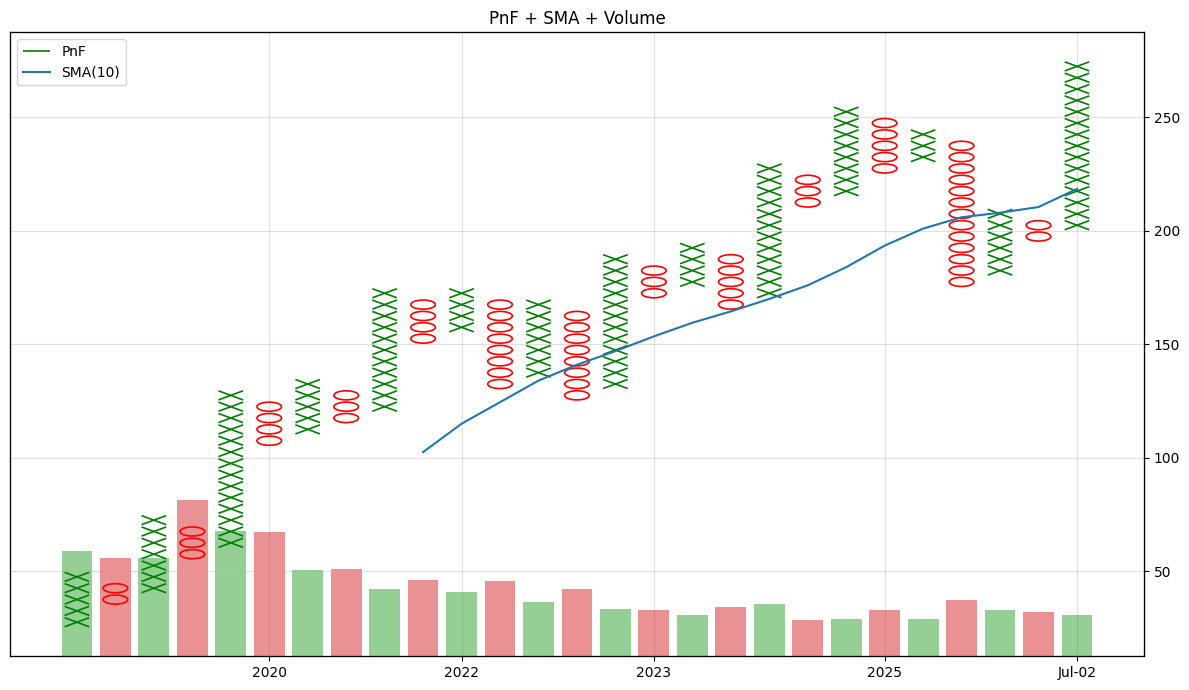

In [7]:
from mplchart.indicators import SMA

Chart(recent, title="PnF + SMA + Volume", max_bars=60, figsize=(12, 7)).plot(
    [PointFigure(box_size=5.0), SMA(10), Volume()]
).show()


## Polars backend


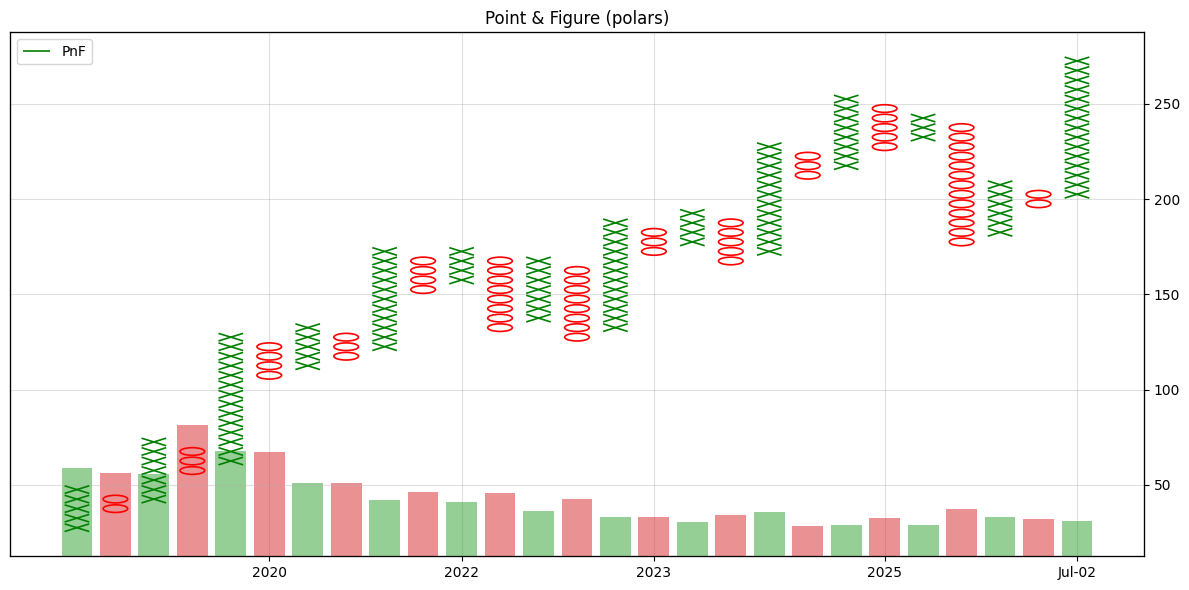

In [8]:
pl_recent = sample_prices(freq="daily", backend="polars").tail(2500)

Chart(pl_recent, title="Point & Figure (polars)", max_bars=60, figsize=(12, 6)).plot(
    [PointFigure(box_size=5.0), Volume()]
).show()


## Findings

- Target API achieved end to end: `Chart(prices).plot(PointFigure(box_size=5.0))` — the primitive binds the transform via `chart.get_view(transform=...)` (bound method; `functools.partial` would work identically) and must be the first view-toucher.
- Same mapping as renko, zero further Chart changes — and *no* timestamp nudge needed: column start dates are strictly increasing, so pandas date-aligned slicing stays 1:1.
- The column frame encodes X/O direction intrabar (close vs open), the same criterion Candlesticks uses — `calc_pnf` output even renders passably under plain `Candlesticks()` as column bars.
- Box-size inference from the grid (smallest level gap) works but is a workaround for frames not carrying metadata — with the primitive now owning `box_size`, the explicit param covers the common case and inference only backs the auto default.
- Close-based columns for the proto; classical PnF uses high/low (X extends on the high, O on the low) — a `method="close"|"hl"` param on promotion.
- Volume: lifetime accumulation (including the closing reversal bar) *averaged over the column's bar count* — mean daily volume while the column formed, a participation rate independent of box size. Per-box averaging was tried first but conflates volume with bars-per-box, which shrinks as a fixed dollar box gets relatively smaller at higher prices (looked like a fake downtrend). Totals are recoverable by multiplying back by the bar count. (Renko differs: per-box totals, even-split on multi-brick bars; see renko-proto.)
- A fixed dollar box over long histories remains the structural issue — percentage (log) boxes are the promotion-time answer.
- Marks fill the cells between bottom and top ((top-bottom)/box cells per column); traditional box counting quibbles can wait.
